<a href="https://colab.research.google.com/github/krishnajaindev/netflix-analysis/blob/main/Netflix%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Netflix Analysis



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Team
##### **Team Member 1 - Krishna Jain
##### **Team Member 2 - Hitarth Singaria


# **Project Summary -**

Netflix is one of the world's largest streaming platforms, offering thousands of Movies and TV Shows to its subscribers across the globe. This project performs an **Exploratory Data Analysis (EDA)** on a dataset of **7,787 Netflix titles**, each described by 12 attributes such as `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `genres`, and `description`.

The goal of this project is simple: **look at the raw data and turn it into a story**. We are not building a machine learning model here — EDA is about asking good questions and using tables, numbers, and charts to answer them.

We started by **understanding the dataset**: its shape (7,787 rows and 12 columns), its data types, and where it had missing values. We found that `director` (2,389 missing), `cast` (718 missing), `country` (507 missing), `date_added` (10 missing), and `rating` (7 missing) all had gaps, while there were **zero duplicate rows**. Rather than deleting this data, we filled missing categorical fields with a clear label (`"Not Specified"`) so we don't lose the row entirely, and filled the handful of missing ratings with the most common rating.

Next, in **Data Wrangling**, we prepared the dataset for analysis: we converted the text `date_added` column into a real date, and pulled out the `year_added` and `month_added` from it. Several columns like `genres`, `cast`, and `country` contain **multiple comma-separated values in a single cell** (e.g. one title can belong to 3 genres and be produced in 2 countries), so we "exploded" these columns wherever we needed to count individual genres, actors, or countries fairly.

In the **Visualization** section, we created 15 charts to explore the data from every angle: the split between Movies and TV Shows (about 69% Movies vs 31% TV Shows), the countries producing the most content (the United States and India lead by a wide margin), how many titles Netflix added every year (huge growth from 2016 to a peak in 2019), the most common content ratings (`TV-MA` and `TV-14` dominate, showing a catalog skewed toward mature audiences), the most frequent genres (International Movies, Dramas, and Comedies top the list), typical movie length (around 90-115 minutes), how many seasons TV shows usually run for (most only ever get **one season**), the most recurring directors and actors, seasonal patterns in when content is added (December and October are the busiest months), and how the Movie/TV Show mix differs by country (India's catalog is overwhelmingly movies, while the UK has a much more balanced mix).

Finally, we tied these findings back to a **business objective**: helping a content strategy team decide where to invest next — in more original TV Shows, in underrepresented regions, and in filling gaps in the ratings/genre mix — and we summarized this into clear, actionable recommendations in the conclusion.

This project is a good example of how raw, messy, real-world data (with missing values, multi-valued columns, and inconsistent formats) can be cleaned and explored using **Python, Pandas, Matplotlib, and Seaborn** to produce genuinely useful business insights.


# **GitHub Link -**

https://github.com/krishnajaindev/netflix-analysis

# **Problem Statement**


Netflix's content library has grown into thousands of Movies and TV Shows sourced from many countries, genres, directors, and cast members. With so much variety, it becomes hard for a content or business team to answer simple but important questions just by looking at spreadsheets:

- Does Netflix lean more towards Movies or TV Shows?
- Which countries and genres dominate the catalog, and which are underrepresented?
- Is the content mostly meant for mature audiences or for a general/family audience?
- How has the size of the catalog changed year over year?
- Are there patterns in *when* content gets added to the platform?

**The goal of this EDA is to explore the Netflix dataset and answer these questions using data, uncovering patterns and insights that can guide content strategy decisions.**

#### **Define Your Business Objective?**

The business objective is to help Netflix's **content acquisition and strategy team** understand the current shape of the catalog — its content type mix, genre and country strengths, audience-rating skew, and growth trend over time — so they can make **data-driven decisions** about:
1. Where to invest more (e.g., more Originals in a particular genre or region)
2. Which audience segments (by rating/age group) may be underserved
3. How to time major content releases throughout the year

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [8]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

%matplotlib inline

### Dataset Loading

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NetFlix.csv')

### Dataset First View

In [11]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


### Dataset Rows & Columns count

In [12]:
# Dataset Rows & Columns count
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 7787
Number of Columns : 12


### Dataset Information

In [13]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


#### Duplicate Values

In [14]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows in the dataset:", duplicate_count)

Number of duplicate rows in the dataset: 0


#### Missing Values/Null Values

In [15]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


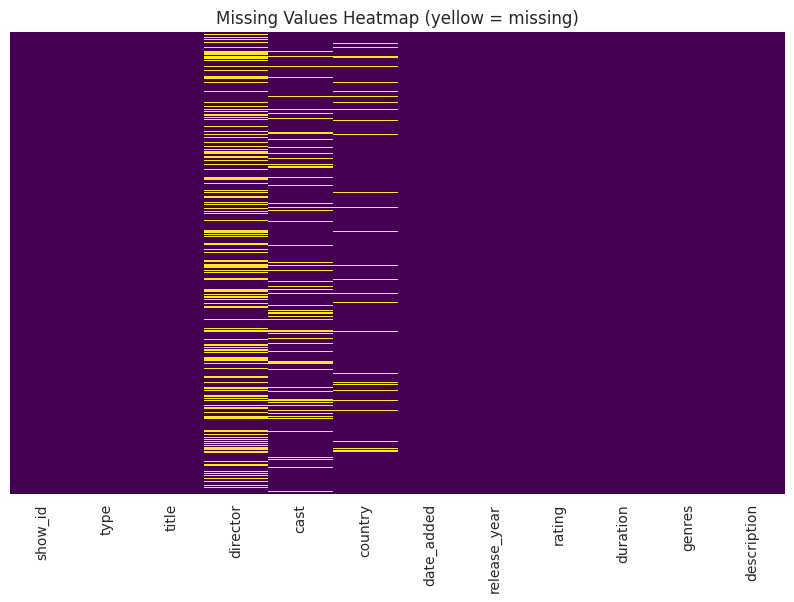

In [16]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (yellow = missing)')
plt.show()

### What did you know about your dataset?

- The dataset has **7,787 rows** and **12 columns**.
- Each row represents one Netflix title, and the columns describe its `type` (Movie/TV Show), `title`, `director`, `cast`, `country`, `date_added` (to Netflix), `release_year`, `rating`, `duration`, `genres` and `description`.
- There are **no duplicate rows** in the dataset — every title appears only once.
- Several columns have missing values: `director` (2,389 missing), `cast` (718 missing), `country` (507 missing), `date_added` (10 missing), and `rating` (only 7 missing). This makes sense — many titles (especially documentaries or stand-up specials) genuinely don't have a listed "cast", and country info isn't always provided by the studio.
- The dataset contains **5,377 Movies** and **2,410 TV Shows** — so Movies make up roughly 69% of the catalog.
- `release_year` ranges from as far back as **1925** all the way to **2021**, but as we'll see, most content is from the last decade.
- Columns like `genres`, `cast`, and `country` are **multi-valued** — a single cell can contain several comma-separated values (e.g. `"Dramas, International Movies, Romantic Movies"`). We need to keep this in mind during analysis so we don't undercount things.

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns

In [18]:
# Dataset Describe

### Variables Description

Answer Here

### Check Unique Values for each variable.

In [19]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [20]:
# Write your code to make your dataset analysis ready.

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [21]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [22]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [23]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [24]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [25]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [26]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [27]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [28]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [29]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [30]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [31]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [32]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [33]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [34]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [35]:
# Pair Plot visualization code

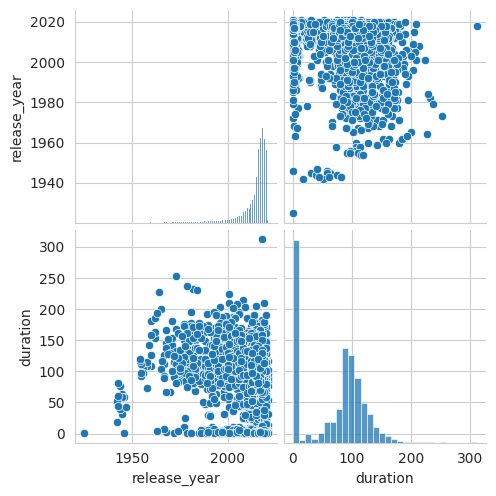

In [36]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [37]:
8882582016

8882582016